In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les visualisations
plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

# Préparation du dataset

In [2]:
# 1.1 Importation du dataset
print("1.1 Importation du dataset")

df = pd.read_csv("heart.csv")
print(f"Dataset importé avec succès: {df.shape[0]} lignes et {df.shape[1]} colonnes.")

1.1 Importation du dataset
Dataset importé avec succès: 303 lignes et 14 colonnes.


 Vérification des données du dataset

In [3]:
print("\n1.2 Vérification des données du dataset")
print("Informations sur le dataset:")
print(df.info())


1.2 Vérification des données du dataset
Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [4]:
print("\nDescription statistique des données numériques:")
print(df.describe())


Description statistique des données numériques:
              age         sex          cp      trtbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg    thalachh        exng     oldpeak         slp         caa  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.

In [5]:
print("\nVérification des valeurs manquantes:")
print(df.isnull().sum())


Vérification des valeurs manquantes:
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


Répartition des classes

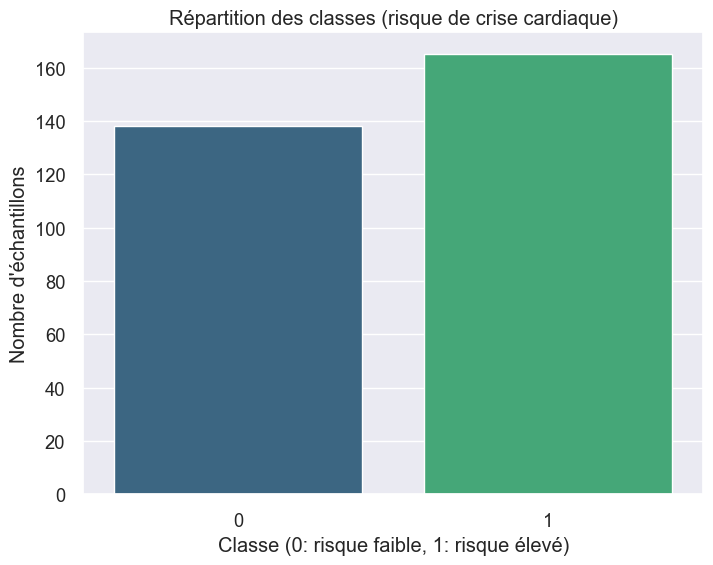

Répartition des classes:
output
1    165
0    138
Name: count, dtype: int64
Pourcentage de risque élevé: 54.46%


In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(x='output', data=df, palette='viridis')
plt.title('Répartition des classes (risque de crise cardiaque)')
plt.xlabel('Classe (0: risque faible, 1: risque élevé)')
plt.ylabel('Nombre d\'échantillons')
plt.show()
plt.savefig('repartition_classes.png')
plt.close()

print(f"Répartition des classes:\n{df['output'].value_counts()}")
print(f"Pourcentage de risque élevé: {df['output'].mean()*100:.2f}%")


Encoder les variables qualitatives

In [7]:

print("\n1.4 Encodage des variables qualitatives")
# Identifier les variables catégorielles (dans notre cas, elles sont déjà encodées numériquement)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall']
numerical_features = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

print(f"Variables catégorielles: {categorical_features}")
print(f"Variables numériques: {numerical_features}")



1.4 Encodage des variables qualitatives
Variables catégorielles: ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall']
Variables numériques: ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']


Feature scaling et preprocessing

In [8]:
# Préparation du preprocessing
X = df.drop('output', axis=1)
y = df['output']

# Création d'un pipeline de prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

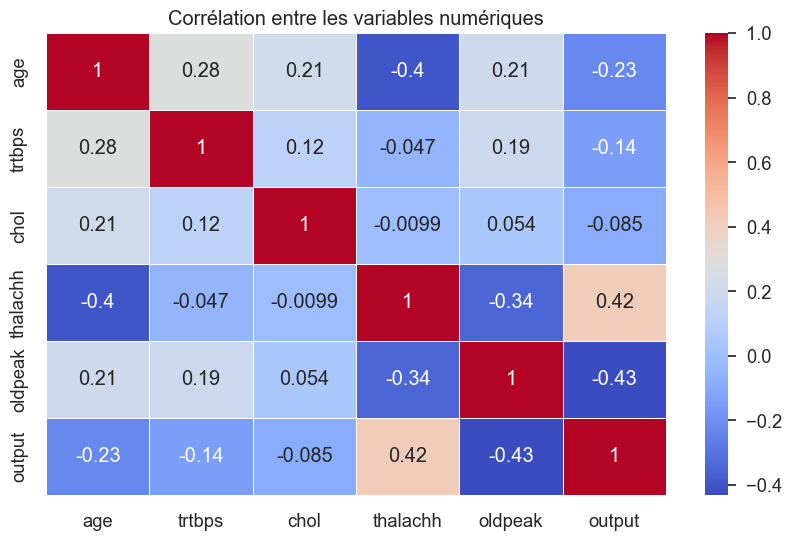

In [9]:
# Visualisation de la corrélation entre les features
plt.figure(figsize=(10, 6))
correlation_matrix = df[numerical_features + ['output']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Corrélation entre les variables numériques')
plt.savefig('correlation_matrix.png')
plt.show()
plt.close()

Partitionnement du Dataset

In [10]:
print("Partitionnement du Dataset")
# Séparation en jeux d'entraînement et de test (75% / 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Taille du jeu d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille du jeu de test: {X_test.shape[0]} échantillons")

Partitionnement du Dataset
Taille du jeu d'entraînement: 227 échantillons
Taille du jeu de test: 76 échantillons


# Apprentissage

In [11]:
# Fonction pour évaluer et afficher les performances d'un modèle
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # Entraînement
    print(f"\nEntraînement du modèle {name}...")
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Évaluation
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"Performance du modèle {name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Matrice de confusion:")
    print(conf_matrix)
    
    # Visualisation de la matrice de confusion
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Risque faible', 'Risque élevé'],
                yticklabels=['Risque faible', 'Risque élevé'])
    plt.xlabel('Prédiction')
    plt.ylabel('Réel')
    plt.title(f'Matrice de confusion - {name}')
    plt.savefig(f'confusion_matrix_{name}.png')
    plt.show()
    plt.close()
    
    # Afficher le rapport de classification complet
    print("\nRapport de classification:")
    print(classification_report(y_test, y_pred))
    
    return accuracy, f1, conf_matrix, model

K-PPV (k=5)

Classification avec K-PPV (k=5)

Entraînement du modèle K-PPV (k=5)...
Performance du modèle K-PPV (k=5):
Accuracy: 0.7500
F1 Score: 0.7711
Matrice de confusion:
[[25 10]
 [ 9 32]]


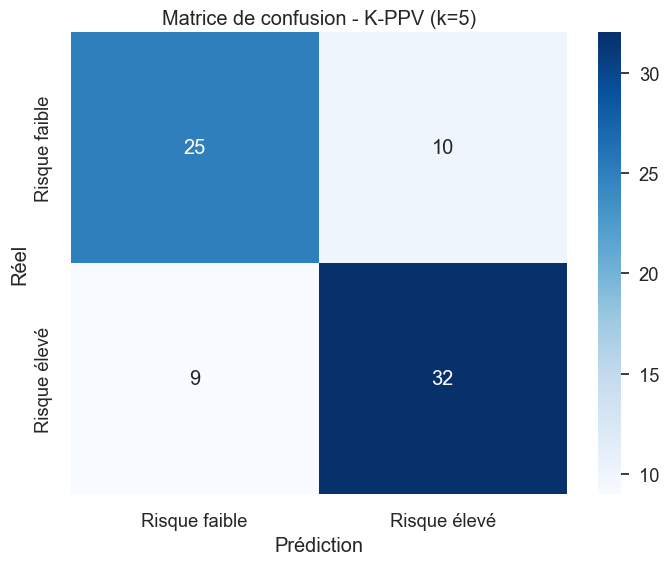


Rapport de classification:
              precision    recall  f1-score   support

           0       0.74      0.71      0.72        35
           1       0.76      0.78      0.77        41

    accuracy                           0.75        76
   macro avg       0.75      0.75      0.75        76
weighted avg       0.75      0.75      0.75        76



In [12]:
print("Classification avec K-PPV (k=5)")
# Pipeline pour K-PPV avec k=5
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Évaluation du modèle K-PPV avec k=5
knn_accuracy, knn_f1, knn_cm, knn_model = evaluate_model("K-PPV (k=5)", knn_pipeline, X_train, X_test, y_train, y_test)


Variation de k et analyse des résultats pour K-PPV:
Meilleur k trouvé: 19 avec une précision de 0.8026

Entraînement du modèle K-PPV (k=19)...
Performance du modèle K-PPV (k=19):
Accuracy: 0.8026
F1 Score: 0.8276
Matrice de confusion:
[[25 10]
 [ 5 36]]


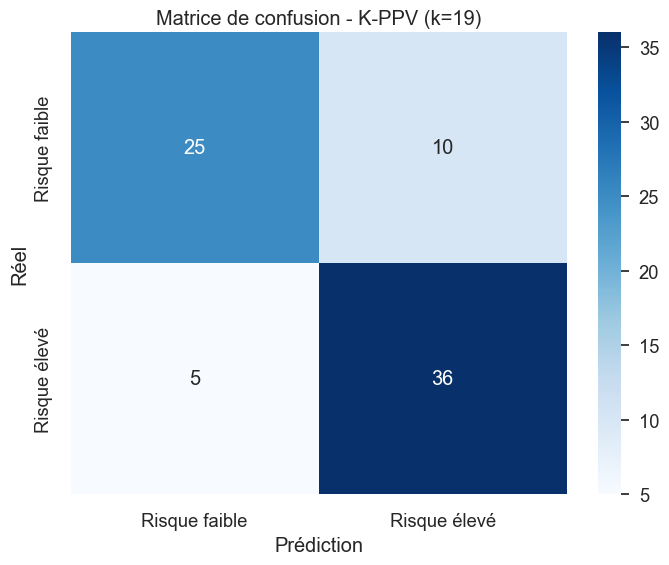


Rapport de classification:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        35
           1       0.78      0.88      0.83        41

    accuracy                           0.80        76
   macro avg       0.81      0.80      0.80        76
weighted avg       0.81      0.80      0.80        76



In [13]:
# Variation de k et analyse des résultats
print("\nVariation de k et analyse des résultats pour K-PPV:")
k_values = list(range(1, 21))
train_scores = []
test_scores = []

for k in k_values:
    knn = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test)))

# Détermination du meilleur k
best_k = k_values[np.argmax(test_scores)]
print(f"Meilleur k trouvé: {best_k} avec une précision de {max(test_scores):.4f}")

# Réévaluation avec le meilleur k
knn_best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=best_k))
])

knn_best_accuracy, knn_best_f1, knn_best_cm, knn_best_model = evaluate_model(
    f"K-PPV (k={best_k})", knn_best_pipeline, X_train, X_test, y_train, y_test
)


Visualisation de l'impact de k sur les performances

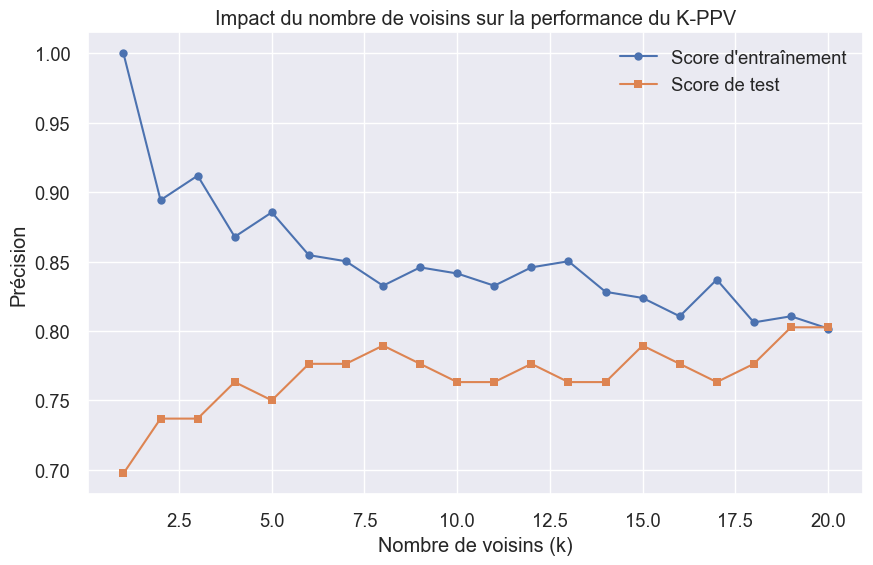

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Score d\'entraînement')
plt.plot(k_values, test_scores, 's-', label='Score de test')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Précision')
plt.title('Impact du nombre de voisins sur la performance du K-PPV')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('knn_k_analysis.png')
plt.close()

Multi-Layer Perceptron (MLP)

 Classification avec Multi-Layer Perceptron (MLP)

Entraînement du modèle MLP...
Performance du modèle MLP:
Accuracy: 0.7500
F1 Score: 0.7765
Matrice de confusion:
[[24 11]
 [ 8 33]]


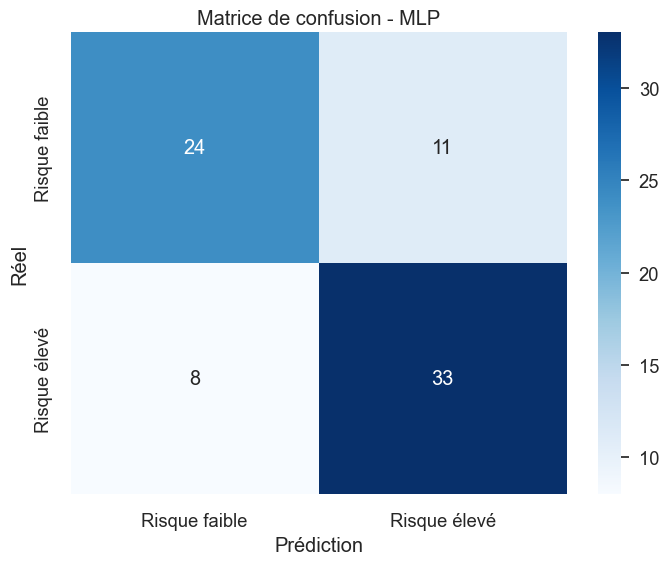


Rapport de classification:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72        35
           1       0.75      0.80      0.78        41

    accuracy                           0.75        76
   macro avg       0.75      0.75      0.75        76
weighted avg       0.75      0.75      0.75        76



In [15]:
print(" Classification avec Multi-Layer Perceptron (MLP)")
# Pipeline pour MLP avec des paramètres par défaut
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))
])
# Évaluation du modèle MLP
mlp_accuracy, mlp_f1, mlp_cm, mlp_model = evaluate_model("MLP", mlp_pipeline, X_train, X_test, y_train, y_test)


 Recherche des meilleurs hyperparamètres pour MLP


Recherche des meilleurs hyperparamètres pour MLP...
Meilleurs paramètres pour MLP: {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'constant'}
Meilleur score F1 (CV): nan

Entraînement du modèle MLP (meilleurs paramètres)...
Performance du modèle MLP (meilleurs paramètres):
Accuracy: 0.7632
F1 Score: 0.7907
Matrice de confusion:
[[24 11]
 [ 7 34]]


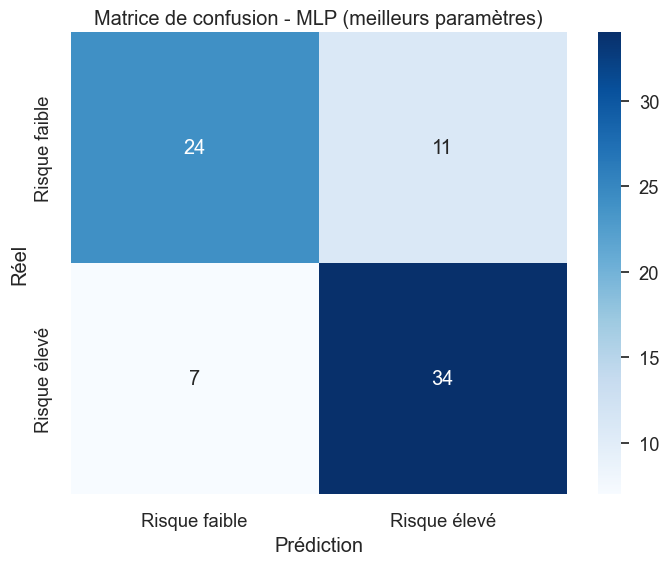


Rapport de classification:
              precision    recall  f1-score   support

           0       0.77      0.69      0.73        35
           1       0.76      0.83      0.79        41

    accuracy                           0.76        76
   macro avg       0.76      0.76      0.76        76
weighted avg       0.76      0.76      0.76        76



In [16]:
print("\nRecherche des meilleurs hyperparamètres pour MLP...")
param_grid_mlp = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate': ['constant', 'adaptive']
}

grid_search_mlp = GridSearchCV(mlp_pipeline, param_grid_mlp, cv=5, scoring='f1', n_jobs=-1)
grid_search_mlp.fit(X_train, y_train)

print(f"Meilleurs paramètres pour MLP: {grid_search_mlp.best_params_}")
print(f"Meilleur score F1 (CV): {grid_search_mlp.best_score_:.4f}")

# Réévaluation avec les meilleurs paramètres
mlp_best_accuracy, mlp_best_f1, mlp_best_cm, mlp_best_model = evaluate_model(
    "MLP (meilleurs paramètres)", grid_search_mlp.best_estimator_, X_train, X_test, y_train, y_test
)

SVM avec différents noyaux

Classification avec SVM (différents noyaux)

Entraînement SVM avec noyau rbf
Meilleurs paramètres pour SVM avec noyau rbf:
{'classifier__C': 0.1, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): nan

Entraînement du modèle SVM (rbf)...
Performance du modèle SVM (rbf):
Accuracy: 0.7500
F1 Score: 0.7765
Matrice de confusion:
[[24 11]
 [ 8 33]]


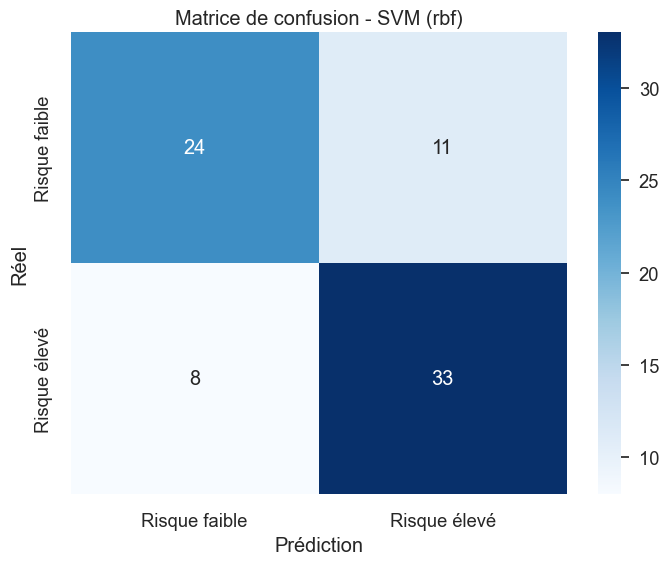


Rapport de classification:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72        35
           1       0.75      0.80      0.78        41

    accuracy                           0.75        76
   macro avg       0.75      0.75      0.75        76
weighted avg       0.75      0.75      0.75        76


Entraînement SVM avec noyau poly
Meilleurs paramètres pour SVM avec noyau poly:
{'classifier__C': 0.1, 'classifier__degree': 2, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): nan

Entraînement du modèle SVM (poly)...
Performance du modèle SVM (poly):
Accuracy: 0.7368
F1 Score: 0.7917
Matrice de confusion:
[[18 17]
 [ 3 38]]


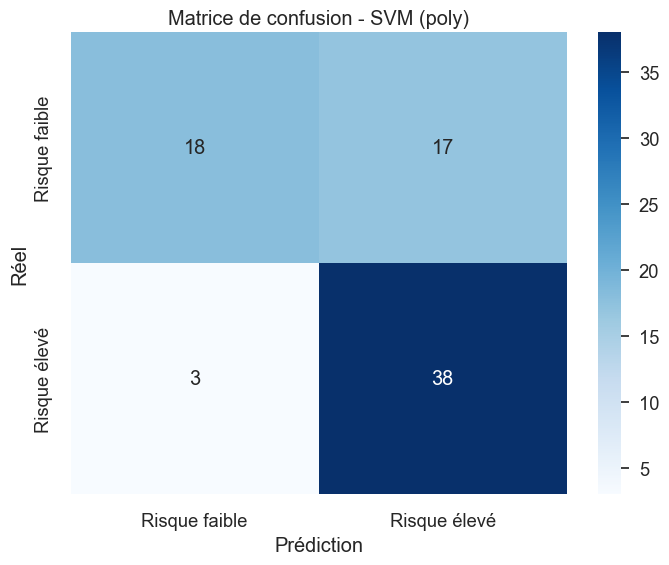


Rapport de classification:
              precision    recall  f1-score   support

           0       0.86      0.51      0.64        35
           1       0.69      0.93      0.79        41

    accuracy                           0.74        76
   macro avg       0.77      0.72      0.72        76
weighted avg       0.77      0.74      0.72        76


Entraînement SVM avec noyau sigmoid
Meilleurs paramètres pour SVM avec noyau sigmoid:
{'classifier__C': 0.1, 'classifier__gamma': 'scale'}
Meilleur score F1 (CV): nan

Entraînement du modèle SVM (sigmoid)...
Performance du modèle SVM (sigmoid):
Accuracy: 0.7895
F1 Score: 0.8095
Matrice de confusion:
[[26  9]
 [ 7 34]]


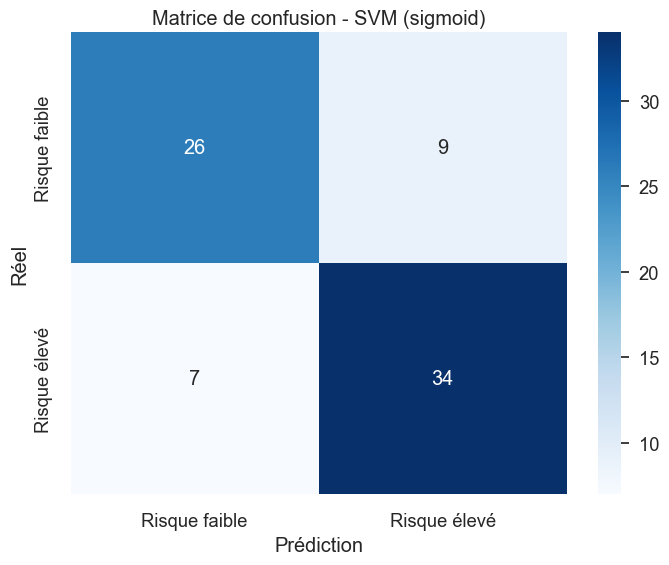


Rapport de classification:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76        35
           1       0.79      0.83      0.81        41

    accuracy                           0.79        76
   macro avg       0.79      0.79      0.79        76
weighted avg       0.79      0.79      0.79        76


Meilleur noyau SVM: sigmoid
F1 Score: 0.8095
Paramètres: {'classifier__C': 0.1, 'classifier__gamma': 'scale'}


In [17]:
print("Classification avec SVM (différents noyaux)")

# Pour chaque type de noyau, définir une plage d'hyperparamètres à tester
kernels = ['rbf', 'poly', 'sigmoid']
svm_results = {}

for kernel in kernels:
    print(f"\nEntraînement SVM avec noyau {kernel}")
    
    # Définir les paramètres de recherche pour chaque noyau
    if kernel == 'rbf':
        param_grid = {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        }
    elif kernel == 'poly':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__degree': [2, 3, 4],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1]
        }
    elif kernel == 'sigmoid':
        param_grid = {
            'classifier__C': [0.1, 1, 10],
            'classifier__gamma': ['scale', 'auto', 0.01, 0.1, 1]
        }
    
    # Définir le pipeline avec le noyau actuel
    svm_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(kernel=kernel, random_state=42))
    ])
    
    # Recherche par validation croisée
    grid_search = GridSearchCV(svm_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    print(f"Meilleurs paramètres pour SVM avec noyau {kernel}:")
    print(grid_search.best_params_)
    print(f"Meilleur score F1 (CV): {grid_search.best_score_:.4f}")
    
    # Évaluer le modèle avec les meilleurs paramètres
    accuracy, f1, cm, model = evaluate_model(
        f"SVM ({kernel})", grid_search.best_estimator_, X_train, X_test, y_train, y_test
    )
    
    svm_results[kernel] = {
        'accuracy': accuracy,
        'f1': f1,
        'model': model,
        'best_params': grid_search.best_params_
    }

# Déterminer le meilleur noyau SVM
best_kernel = max(svm_results.keys(), key=lambda k: svm_results[k]['f1'])
print(f"\nMeilleur noyau SVM: {best_kernel}")
print(f"F1 Score: {svm_results[best_kernel]['f1']:.4f}")
print(f"Paramètres: {svm_results[best_kernel]['best_params']}")

Évaluation comparative des performances

In [18]:
print("\nIII. ÉVALUATION COMPARATIVE DES PERFORMANCES")
print("==========================================")

# Collecter les résultats de tous les modèles
models_results = {
    f"K-PPV (k={best_k})": {'accuracy': knn_best_accuracy, 'f1': knn_best_f1},
    "MLP (meilleurs params)": {'accuracy': mlp_best_f1, 'f1': mlp_best_f1}
}

for kernel in svm_results:
    models_results[f"SVM ({kernel})"] = {
        'accuracy': svm_results[kernel]['accuracy'], 
        'f1': svm_results[kernel]['f1']
    }

# Créer un DataFrame pour la comparaison
comparison_df = pd.DataFrame({
    'Modèle': list(models_results.keys()),
    'Accuracy': [models_results[model]['accuracy'] for model in models_results],
    'F1 Score': [models_results[model]['f1'] for model in models_results]
})

print("Comparaison des performances:")
print(comparison_df)

# Déterminer le meilleur modèle global
best_model_name = max(models_results.keys(), key=lambda k: models_results[k]['f1'])
print(f"\nMeilleur modèle global: {best_model_name}")
print(f"F1 Score: {models_results[best_model_name]['f1']:.4f}")
print(f"Accuracy: {models_results[best_model_name]['accuracy']:.4f}")

# IV. Conclusion
print("\nIV. CONCLUSION")
print("============")
print("Cette étude a comparé trois méthodes de classification pour l'analyse des risques de crise cardiaque:")
print("1. K-PPV avec différentes valeurs de k")
print("2. MLP avec optimisation des hyperparamètres")
print("3. SVM avec différents noyaux (RBF, polynomial, sigmoïde)")

print(f"\nLe meilleur modèle est {best_model_name} avec un F1 Score de {models_results[best_model_name]['f1']:.4f}.")
print("Les facteurs les plus influents dans la prédiction du risque de crise cardiaque peuvent être analysés ")
print("en examinant les caractéristiques du modèle et leur importance relative.")




III. ÉVALUATION COMPARATIVE DES PERFORMANCES
Comparaison des performances:
                   Modèle  Accuracy  F1 Score
0            K-PPV (k=19)  0.802632  0.827586
1  MLP (meilleurs params)  0.790698  0.790698
2               SVM (rbf)  0.750000  0.776471
3              SVM (poly)  0.736842  0.791667
4           SVM (sigmoid)  0.789474  0.809524

Meilleur modèle global: K-PPV (k=19)
F1 Score: 0.8276
Accuracy: 0.8026

IV. CONCLUSION
Cette étude a comparé trois méthodes de classification pour l'analyse des risques de crise cardiaque:
1. K-PPV avec différentes valeurs de k
2. MLP avec optimisation des hyperparamètres
3. SVM avec différents noyaux (RBF, polynomial, sigmoïde)

Le meilleur modèle est K-PPV (k=19) avec un F1 Score de 0.8276.
Les facteurs les plus influents dans la prédiction du risque de crise cardiaque peuvent être analysés 
en examinant les caractéristiques du modèle et leur importance relative.


Visualisation des performances


<Figure size 1200x600 with 0 Axes>

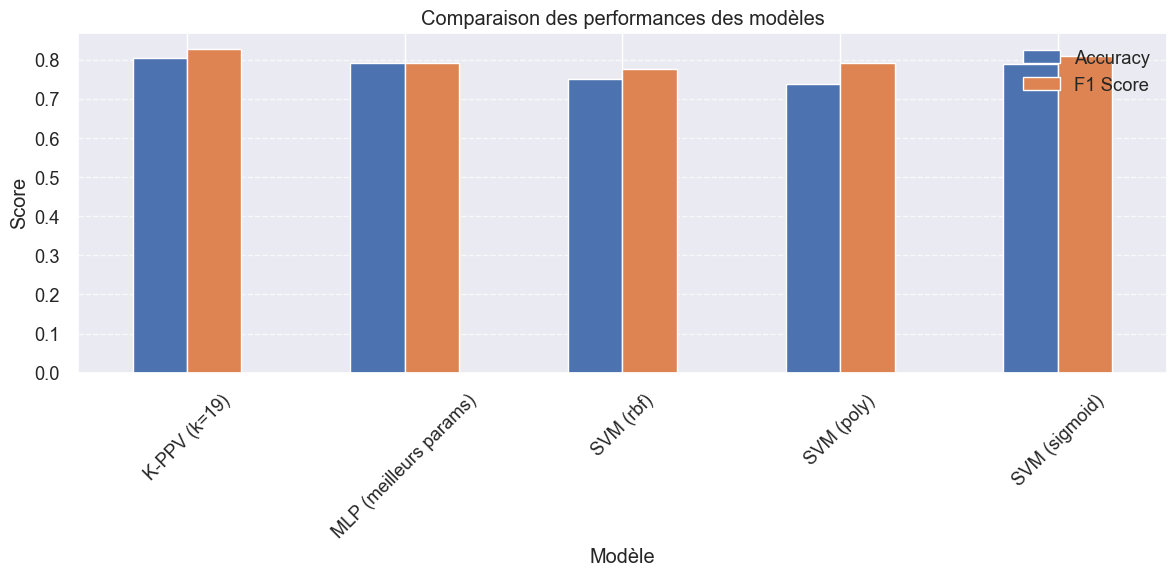

In [19]:
plt.figure(figsize=(12, 6))
comparison_df.set_index('Modèle').plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des performances des modèles')
plt.ylabel('Score')
plt.xlabel('Modèle')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()  
plt.close()